# 1. Configuración de Entorno y Memoria
Configuramos variables de entorno para evitar la fragmentación de la VRAM y creamos una función para limpiar la basura de la GPU entre ejecuciones.


In [4]:
import os
# Evitar fragmentación de memoria en PyTorch
os.environ["PYTORCH_ALLOC_CONF"] = "expandable_segments:True"

import gc
import torch
import torch.nn as nn
import torch.optim as optim
import lightning as L
from lightning.pytorch.callbacks.early_stopping import EarlyStopping
from lightning.pytorch.loggers import CSVLogger
from lightning.pytorch.tuner import Tuner
import torchvision
from torchvision.transforms import v2
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, random_split, Subset
import matplotlib.pyplot as plt
import random
import numpy as np

def cleanup():
    """Fuerza la recolección de basura y vacía la caché de CUDA"""
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()
        
print(f"CUDA available: {torch.cuda.is_available()}")

CUDA available: False


In [2]:
%matplotlib inline


# 2. Carga de Datos (DataModule)
Separamos las transformaciones de CPU (lectura) y GPU (matemáticas pesadas). Usamos LightningDataModule para una gestión limpia.


In [3]:
# Transformaciones BASE (CPU) - Leer, redimensionar y pasar a Tensor [0, 1]
base_transforms = v2.Compose([
    v2.Grayscale(num_output_channels=1),
    v2.Resize((100, 100)),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True)
])

# Transformaciones de Aumento (GPU)
gpu_train_transforms = v2.Compose([
    v2.RandomHorizontalFlip(p=0.5),
    v2.RandomVerticalFlip(p=0.2),
    v2.RandomRotation(20),
    v2.Normalize(mean=[0.5], std=[0.5])
])

gpu_val_test_transforms = v2.Compose([
    v2.Normalize(mean=[0.5], std=[0.5])
])

class AnukaDataModule(L.LightningDataModule):
    def __init__(self, dataset_path, batch_size=64, num_workers=4):
        super().__init__()
        self.dataset_path = dataset_path
        self.batch_size = batch_size
        self.num_workers = num_workers
        self.base_transforms = base_transforms

    def setup(self, stage=None):
        dataset = ImageFolder(root=self.dataset_path, transform=self.base_transforms)
        total_size = len(dataset)
        indices = list(range(total_size))
        train_indices, val_indices, test_indices = random_split(
            indices, [0.8, 0.1, 0.1], generator=torch.Generator().manual_seed(42)
        )
        self.train_ds = Subset(dataset, train_indices)
        self.val_ds = Subset(dataset, val_indices)
        self.test_ds = Subset(dataset, test_indices)
        self.classes = dataset.classes

    def train_dataloader(self):
        return DataLoader(self.train_ds, batch_size=self.batch_size, shuffle=True, 
                          num_workers=self.num_workers, pin_memory=True, persistent_workers=True)

    def val_dataloader(self):
        return DataLoader(self.val_ds, batch_size=self.batch_size, shuffle=False, 
                          num_workers=self.num_workers, pin_memory=True, persistent_workers=True)

    def test_dataloader(self):
        return DataLoader(self.test_ds, batch_size=self.batch_size, shuffle=False, 
                          num_workers=self.num_workers, pin_memory=True, persistent_workers=True)

# Instanciamos el DataModule con un batch_size base (lo optimizaremos luego)
dm = AnukaDataModule(dataset_path='dataset/anuka1200', batch_size=32, num_workers=4)
dm.setup()
print(f"Classes: {dm.classes}, Train size: {len(dm.train_ds)}")

Classes: ['Tipo A: Kunzea', 'Tipo B: Lepto'], Train size: 1920


# 3. Definición del Módulo de Entrenamiento
Añadimos `on_after_batch_transfer` para ejecutar las transformaciones en la GPU.


In [4]:
class RedNeuronal(L.LightningModule):
    def __init__(self, model, is_cnn=False, lr=1e-3, train_transforms=None, val_transforms=None):
        super().__init__()
        self.save_hyperparameters(ignore=['model', 'train_transforms', 'val_transforms'])
        self.model = model
        self.loss_fn = nn.BCEWithLogitsLoss()
        self.is_cnn = is_cnn
        self.lr = lr
        self.train_transforms = train_transforms
        self.val_transforms = val_transforms

    def on_after_batch_transfer(self, batch, dataloader_idx):
        # Mueve las transformaciones costosas a la GPU (CUDA)
        x, y = batch
        if self.trainer.training and self.train_transforms:
            x = self.train_transforms(x)
        elif self.val_transforms:
            x = self.val_transforms(x)
        return x, y

    def training_step(self, batch, batch_idx):
        x, y = batch
        if not self.is_cnn:
            x = x.view(x.size(0), -1)  
        logits = self.model(x).squeeze(dim=1)
        y = y.float()
        loss = self.loss_fn(logits, y)
        preds = (torch.sigmoid(logits) > 0.5).float()
        accuracy = (preds == y).float().mean()
        self.log('train_loss', loss, prog_bar=True, on_step=False, on_epoch=True)
        self.log('train_accuracy', accuracy, prog_bar=True, on_step=False, on_epoch=True)
        return loss
    
    def validation_step(self, batch, batch_idx):    
        x, y = batch
        if not self.is_cnn:
            x = x.view(x.size(0), -1)  
        logits = self.model(x).squeeze(dim=1)
        y = y.float()
        loss = self.loss_fn(logits, y)
        preds = (torch.sigmoid(logits) > 0.5).float()
        accuracy = (preds == y).float().mean()
        self.log('val_accuracy', accuracy, prog_bar=True, on_step=False, on_epoch=True)
        self.log('val_loss', loss, prog_bar=True, on_step=False, on_epoch=True)
        
    def test_step(self, batch, batch_idx):
        x, y = batch
        if not self.is_cnn:
            x = x.view(x.size(0), -1)  
        logits = self.model(x).squeeze(dim=1)
        y = y.float()
        loss = self.loss_fn(logits, y)
        preds = (torch.sigmoid(logits) > 0.5).float()
        accuracy = (preds == y).float().mean()
        self.log('test_loss', loss, prog_bar=True, on_step=False, on_epoch=True)
        self.log('test_accuracy', accuracy, prog_bar=True, on_step=False, on_epoch=True)

    def configure_optimizers(self):
        optimizer = optim.Adam(self.parameters(), lr=self.lr)
        return optimizer

# 4. Búsqueda de Batch Size Óptimo (Con techo de seguridad)


In [5]:
cleanup() # Aseguramos VRAM limpia

modelo_stress = nn.Sequential(
    nn.Conv2d(1, 16, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
    nn.Conv2d(16, 32, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
    nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
    nn.Flatten(), nn.Linear(64 * 12 * 12, 64), nn.ReLU(), nn.Dropout(0.5), nn.Linear(64, 1)
)

modelo_lig_stress = RedNeuronal(modelo_stress, is_cnn=True, 
                               train_transforms=gpu_train_transforms, 
                               val_transforms=gpu_val_test_transforms)

trainer_finder = L.Trainer(accelerator="gpu", devices=1)
tuner = Tuner(trainer_finder)

print("Buscando el Batch Size máximo...")
try:
    new_batch_size = tuner.scale_batch_size(modelo_lig_stress, 
                                            datamodule=dm,
                                            method="fit",
                                            mode="power",
                                            init_val=32, 
                                            max_trials=8)
    
    # TECHO DE SEGURIDAD: Máximo 256 para evitar OOM durante entrenamientos largos
    batch_size_seguro = min(new_batch_size, 64)
    dm.batch_size = batch_size_seguro
    print(f"Batch size bruto encontrado: {new_batch_size}. Batch size aplicado: {dm.batch_size}")
except Exception as e:
    print(f"Error: {e}")
    print("Manteniendo batch_size=32 por defecto.")
    
# Limpiamos el modelo de estrés
del modelo_stress, modelo_lig_stress, trainer_finder, tuner
cleanup()

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
/home/diego/.pyenv/versions/3.13.3/envs/MineriaDeDatos/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/home/diego/.pyenv/versions/3.13.3/envs/MineriaDeDatos/lib/python3.13/site-packages/lightning/pytorch/loops/utilities.py:7

Buscando el Batch Size máximo...


/home/diego/.pyenv/versions/3.13.3/envs/MineriaDeDatos/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:378: You have overridden `on_after_batch_transfer` in `LightningModule` but have passed in a `LightningDataModule`. It will use the implementation from `LightningModule` instance.
`Trainer.fit` stopped: `max_steps=3` reached.
Batch size 32 succeeded, trying batch size 64
/home/diego/.pyenv/versions/3.13.3/envs/MineriaDeDatos/lib/python3.13/site-packages/lightning/pytorch/loops/fit_loop.py:317: The number of training batches (30) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.
`Trainer.fit` stopped: `max_steps=3` reached.
Batch size 64 succeeded, trying batch size 128
/home/diego/.pyenv/versions/3.13.3/envs/MineriaDeDatos/lib/python3.13/site-packages/lightning/pytorch/loops/fit_loop.py:317: The number of training batches (15) is smaller than th

Batch size bruto encontrado: 2048. Batch size aplicado: 64


# 5. Entrenamiento de Modelos
Parámetros globales para el entrenamiento.


In [6]:
max_epochs = 100
callbacks = [EarlyStopping(monitor="val_loss", mode="min", patience=5)]

## Modelo 1: NET-1 (Regresión Logística)


In [ ]:
cleanup()
net1 = nn.Sequential(nn.Linear(100 * 100, 1))
modelo_net1 = RedNeuronal(net1, is_cnn=False, train_transforms=gpu_train_transforms, val_transforms=gpu_val_test_transforms)

logger_net1 = CSVLogger("logs", name="net1")
trainer_net1 = L.Trainer(max_epochs=max_epochs, logger=logger_net1, callbacks=[EarlyStopping(monitor="val_loss", mode="min", patience=5)])

# LR Finder
Tuner(trainer_net1).lr_find(modelo_net1, datamodule=dm)
print(f"Mejor LR sugerida para NET-1: {modelo_net1.lr}")

# Train & Test
trainer_net1.fit(model=modelo_net1, datamodule=dm)
trainer_net1.test(model=modelo_net1, datamodule=dm)

# Destruir modelo para liberar RAM/VRAM
del net1, modelo_net1, trainer_net1
cleanup()

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
`weights_only` was not set, defaulting to `False`.


Finding best initial lr:   0%|          | 0/100 [00:00<?, ?it/s]

LR finder stopped early after 81 steps due to diverging loss.
Restoring states from the checkpoint path at /home/diego/UNED/MineriaDeDatosUNED/PEC3/.lr_find_54e507ed-f7d6-4b43-81b3-17e80a064e92.ckpt
Restored all states from the checkpoint at /home/diego/UNED/MineriaDeDatosUNED/PEC3/.lr_find_54e507ed-f7d6-4b43-81b3-17e80a064e92.ckpt
Learning rate set to 0.0001445439770745928
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Mejor LR sugerida para NET-1: 0.0001445439770745928


┏━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name             ┃ Type              ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model            │ Sequential        │ 10.0 K │ train │     0 │
│ 1 │ loss_fn          │ BCEWithLogitsLoss │      0 │ train │     0 │
│ 2 │ train_transforms │ Compose           │      0 │ train │     0 │
│ 3 │ val_transforms   │ Compose           │      0 │ train │     0 │
└───┴──────────────────┴───────────────────┴────────┴───────┴───────┘

Trainable params: 10.0 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 10.0 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 5                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       test_accuracy       │    0.8374999761581421     │
│         test_loss         │    0.4164383113384247     │
└───────────────────────────┴───────────────────────────┘

## Modelo 2: NET-2 (Perceptrón Multicapa)


In [8]:
cleanup()
net2 = nn.Sequential(nn.Linear(100 * 100, 128), nn.ReLU(), nn.Linear(128, 64), nn.ReLU(), nn.Linear(64, 1))
modelo_net2 = RedNeuronal(net2, is_cnn=False, train_transforms=gpu_train_transforms, val_transforms=gpu_val_test_transforms)

logger_net2 = CSVLogger("logs", name="net2")
trainer_net2 = L.Trainer(max_epochs=max_epochs, logger=logger_net2, callbacks=[EarlyStopping(monitor="val_loss", mode="min", patience=5)])

Tuner(trainer_net2).lr_find(modelo_net2, datamodule=dm)
trainer_net2.fit(model=modelo_net2, datamodule=dm)
trainer_net2.test(model=modelo_net2, datamodule=dm)

del net2, modelo_net2, trainer_net2
cleanup()

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
`weights_only` was not set, defaulting to `False`.


Finding best initial lr:   0%|          | 0/100 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_steps=100` reached.
Restoring states from the checkpoint path at /home/diego/UNED/MineriaDeDatosUNED/PEC3/.lr_find_993d74cf-c67c-4f48-a246-f3df89d824c8.ckpt
Restored all states from the checkpoint at /home/diego/UNED/MineriaDeDatosUNED/PEC3/.lr_find_993d74cf-c67c-4f48-a246-f3df89d824c8.ckpt
Learning rate set to 6.918309709189363e-05
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name             ┃ Type              ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model            │ Sequential        │  1.3 M │ train │     0 │
│ 1 │ loss_fn          │ BCEWithLogitsLoss │      0 │ train │     0 │
│ 2 │ train_transforms │ Compose           │      0 │ train │     0 │
│ 3 │ val_transforms   │ Compose           │      0 │ train │     0 │
└───┴──────────────────┴───────────────────┴────────┴───────┴───────┘

Trainable params: 1.3 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 1.3 M                                                                                                
Total estimated model params size (MB): 5                                                                          
Modules in train mode: 9                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       test_accuracy       │          0.8125           │
│         test_loss         │    0.41753116250038147    │
└───────────────────────────┴───────────────────────────┘

## Modelo 3: CNN Simple (Base)


In [9]:
cleanup()
cnn_base = nn.Sequential(
    nn.Conv2d(1, 16, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
    nn.Conv2d(16, 32, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
    nn.Flatten(), nn.Linear(32 * 25 * 25, 16), nn.ReLU(), nn.Linear(16, 1)
)
modelo_cnn = RedNeuronal(cnn_base, is_cnn=True, train_transforms=gpu_train_transforms, val_transforms=gpu_val_test_transforms)

logger_cnn = CSVLogger("logs", name="cnn_base")
trainer_cnn = L.Trainer(max_epochs=max_epochs, logger=logger_cnn, callbacks=[EarlyStopping(monitor="val_loss", mode="min", patience=5)])

Tuner(trainer_cnn).lr_find(modelo_cnn, datamodule=dm)
trainer_cnn.fit(model=modelo_cnn, datamodule=dm)
trainer_cnn.test(model=modelo_cnn, datamodule=dm)

del cnn_base, modelo_cnn, trainer_cnn
cleanup()

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
`weights_only` was not set, defaulting to `False`.


Finding best initial lr:   0%|          | 0/100 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_steps=100` reached.
Restoring states from the checkpoint path at /home/diego/UNED/MineriaDeDatosUNED/PEC3/.lr_find_9dd73f33-ea9c-4fbb-a37c-c99969f71885.ckpt
Restored all states from the checkpoint at /home/diego/UNED/MineriaDeDatosUNED/PEC3/.lr_find_9dd73f33-ea9c-4fbb-a37c-c99969f71885.ckpt
Learning rate set to 0.002754228703338169
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name             ┃ Type              ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model            │ Sequential        │  324 K │ train │     0 │
│ 1 │ loss_fn          │ BCEWithLogitsLoss │      0 │ train │     0 │
│ 2 │ train_transforms │ Compose           │      0 │ train │     0 │
│ 3 │ val_transforms   │ Compose           │      0 │ train │     0 │
└───┴──────────────────┴───────────────────┴────────┴───────┴───────┘

Trainable params: 324 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 324 K                                                                                                
Total estimated model params size (MB): 1                                                                          
Modules in train mode: 14                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       test_accuracy       │    0.9291666746139526     │
│         test_loss         │    0.1796746850013733     │
└───────────────────────────┴───────────────────────────┘

## Modelo 4: CNN Variante A (BatchNorm + Dropout)


In [10]:
cleanup()
cnn_a = nn.Sequential(
    nn.Conv2d(1, 16, kernel_size=3, padding=1), nn.BatchNorm2d(16), nn.ReLU(), nn.MaxPool2d(2),
    nn.Conv2d(16, 32, kernel_size=3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
    nn.Flatten(), nn.Linear(32 * 25 * 25, 16), nn.ReLU(), nn.Dropout(0.5), nn.Linear(16, 1)
)
modelo_cnn_a = RedNeuronal(cnn_a, is_cnn=True, train_transforms=gpu_train_transforms, val_transforms=gpu_val_test_transforms)

logger_cnn_a = CSVLogger("logs", name="cnn_var_a")
trainer_cnn_a = L.Trainer(max_epochs=max_epochs, logger=logger_cnn_a, callbacks=[EarlyStopping(monitor="val_loss", mode="min", patience=5)])

Tuner(trainer_cnn_a).lr_find(modelo_cnn_a, datamodule=dm)
trainer_cnn_a.fit(model=modelo_cnn_a, datamodule=dm)
trainer_cnn_a.test(model=modelo_cnn_a, datamodule=dm)

del cnn_a, modelo_cnn_a, trainer_cnn_a
cleanup()

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
`weights_only` was not set, defaulting to `False`.


Finding best initial lr:   0%|          | 0/100 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_steps=100` reached.
Restoring states from the checkpoint path at /home/diego/UNED/MineriaDeDatosUNED/PEC3/.lr_find_ac473903-668c-4de0-8fa6-bd790d63df15.ckpt
Restored all states from the checkpoint at /home/diego/UNED/MineriaDeDatosUNED/PEC3/.lr_find_ac473903-668c-4de0-8fa6-bd790d63df15.ckpt
Learning rate set to 1.9054607179632464e-05
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name             ┃ Type              ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model            │ Sequential        │  324 K │ train │     0 │
│ 1 │ loss_fn          │ BCEWithLogitsLoss │      0 │ train │     0 │
│ 2 │ train_transforms │ Compose           │      0 │ train │     0 │
│ 3 │ val_transforms   │ Compose           │      0 │ train │     0 │
└───┴──────────────────┴───────────────────┴────────┴───────┴───────┘

Trainable params: 324 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 324 K                                                                                                
Total estimated model params size (MB): 1                                                                          
Modules in train mode: 17                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       test_accuracy       │     0.887499988079071     │
│         test_loss         │    0.29421812295913696    │
└───────────────────────────┴───────────────────────────┘

## Modelo 5: CNN Variante B (Profunda con Dropout)


In [11]:
cleanup()
cnn_b = nn.Sequential(
    nn.Conv2d(1, 16, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
    nn.Conv2d(16, 32, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
    nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
    nn.Flatten(), nn.Linear(64 * 12 * 12, 64), nn.ReLU(), nn.Dropout(0.5), nn.Linear(64, 1)
)
modelo_cnn_b = RedNeuronal(cnn_b, is_cnn=True, train_transforms=gpu_train_transforms, val_transforms=gpu_val_test_transforms)

logger_cnn_b = CSVLogger("logs", name="cnn_var_b")
trainer_cnn_b = L.Trainer(max_epochs=max_epochs, logger=logger_cnn_b, callbacks=[EarlyStopping(monitor="val_loss", mode="min", patience=5)])

Tuner(trainer_cnn_b).lr_find(modelo_cnn_b, datamodule=dm)
trainer_cnn_b.fit(model=modelo_cnn_b, datamodule=dm)
trainer_cnn_b.test(model=modelo_cnn_b, datamodule=dm)

del cnn_b, modelo_cnn_b, trainer_cnn_b
cleanup()

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
`weights_only` was not set, defaulting to `False`.


Finding best initial lr:   0%|          | 0/100 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_steps=100` reached.
Restoring states from the checkpoint path at /home/diego/UNED/MineriaDeDatosUNED/PEC3/.lr_find_18e6d728-3ec6-4b0f-a73d-41584a42ca45.ckpt
Restored all states from the checkpoint at /home/diego/UNED/MineriaDeDatosUNED/PEC3/.lr_find_18e6d728-3ec6-4b0f-a73d-41584a42ca45.ckpt
Learning rate set to 0.002754228703338169
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name             ┃ Type              ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model            │ Sequential        │  613 K │ train │     0 │
│ 1 │ loss_fn          │ BCEWithLogitsLoss │      0 │ train │     0 │
│ 2 │ train_transforms │ Compose           │      0 │ train │     0 │
│ 3 │ val_transforms   │ Compose           │      0 │ train │     0 │
└───┴──────────────────┴───────────────────┴────────┴───────┴───────┘

Trainable params: 613 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 613 K                                                                                                
Total estimated model params size (MB): 2                                                                          
Modules in train mode: 18                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       test_accuracy       │    0.9416666626930237     │
│         test_loss         │    0.14906957745552063    │
└───────────────────────────┴───────────────────────────┘

# Fase 3: Análisis de Pesos y Mapas de Características

## 1. Carga del Modelo Base (CNN)
Cargamos los pesos del entrenamiento previo (Fase 2) para el Modelo 3.

In [3]:

cleanup()
# Re-definimos la arquitectura del Modelo 3 (Base)
cnn_base_arch = nn.Sequential(
    nn.Conv2d(1, 16, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
    nn.Conv2d(16, 32, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
    nn.Flatten(), nn.Linear(32 * 25 * 25, 16), nn.ReLU(), nn.Linear(16, 1)
)

# Cargamos el checkpoint (Version 2 fue la más completa)
checkpoint_path = 'logs/cnn_base/version_7/checkpoints/epoch=26-step=810.ckpt'
modelo_visual = RedNeuronal.load_from_checkpoint(
    checkpoint_path, 
    model=cnn_base_arch,
    is_cnn=True
)
modelo_visual.eval() # Modo evaluación
print("Modelo cargado correctamente para análisis.")


NameError: name 'cleanup' is not defined

## 2. Visualización de Filtros (Pesos)
Visualizamos los filtros de la primera capa convolucional para identificar patrones de bajo nivel.

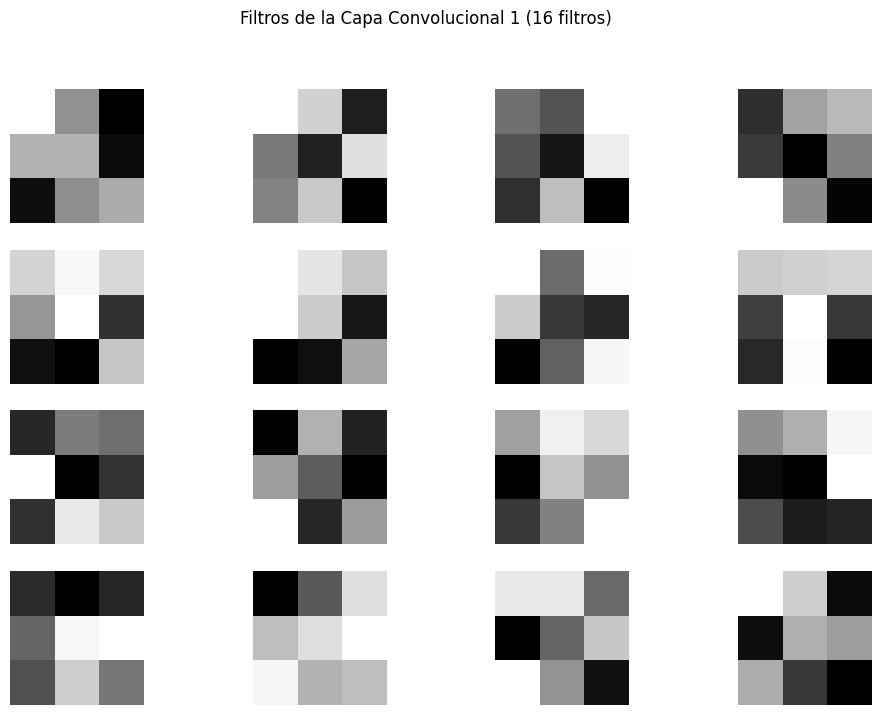

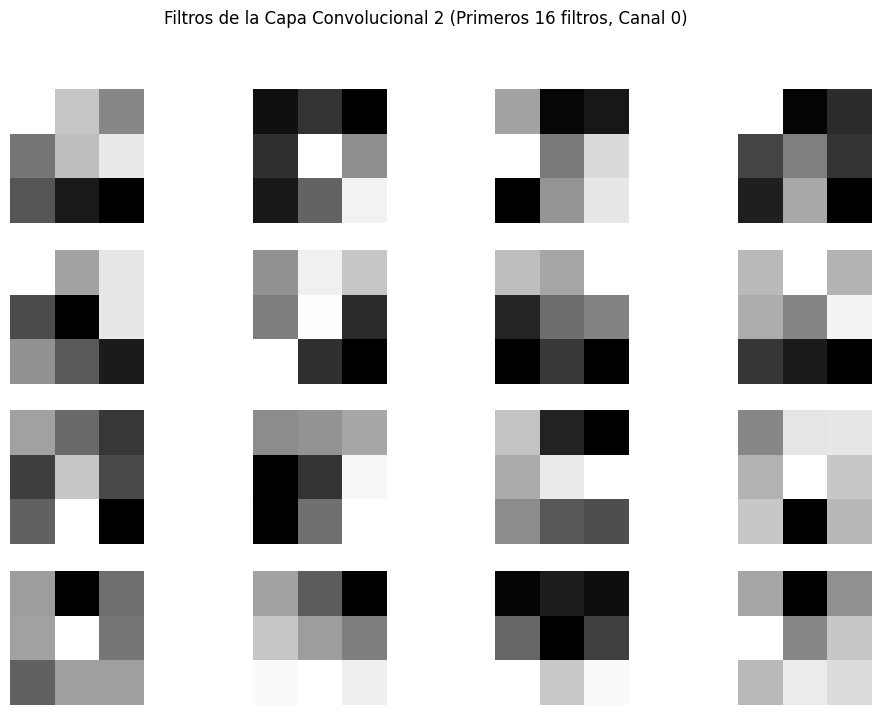

In [16]:
def plot_filters(layer_weights, title, filename=None):
    filters = layer_weights.detach().cpu()
    n_filters = filters.shape[0]
    plt.figure(figsize=(12, 8))
    for i in range(n_filters):
        plt.subplot(4, 4, i + 1)
        # Normalizamos para mejor visualización
        f_min, f_max = filters[i].min(), filters[i].max()
        filter_img = (filters[i] - f_min) / (f_max - f_min)
        plt.imshow(filter_img.squeeze(), cmap='gray')
        plt.axis('off')
    plt.suptitle(title)
    if filename: plt.savefig(filename, bbox_inches='tight')
    plt.show()

# Capa 1: Conv2d(1, 16, ...)
plot_filters(modelo_visual.model[0].weight, "Filtros de la Capa Convolucional 1 (16 filtros)", "filtros_conv1.png")
plt.show()

# Capa 2: Conv2d(16, 32, ...) - Visualizamos solo los primeros 16 del primer canal de entrada
plot_filters(modelo_visual.model[3].weight[:, 0, :, :][:16], "Filtros de la Capa Convolucional 2 (Primeros 16 filtros, Canal 0)", "filtros_conv2.png")


## 3. Visualización de Mapas de Características
Pasamos una imagen por la red y capturamos las activaciones de las capas convolucionales.

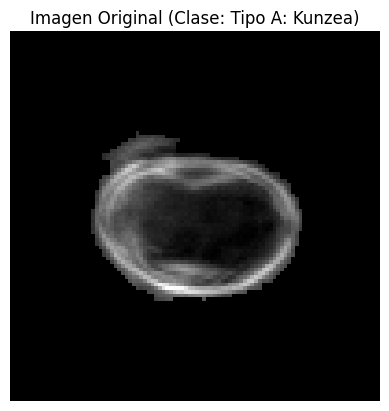

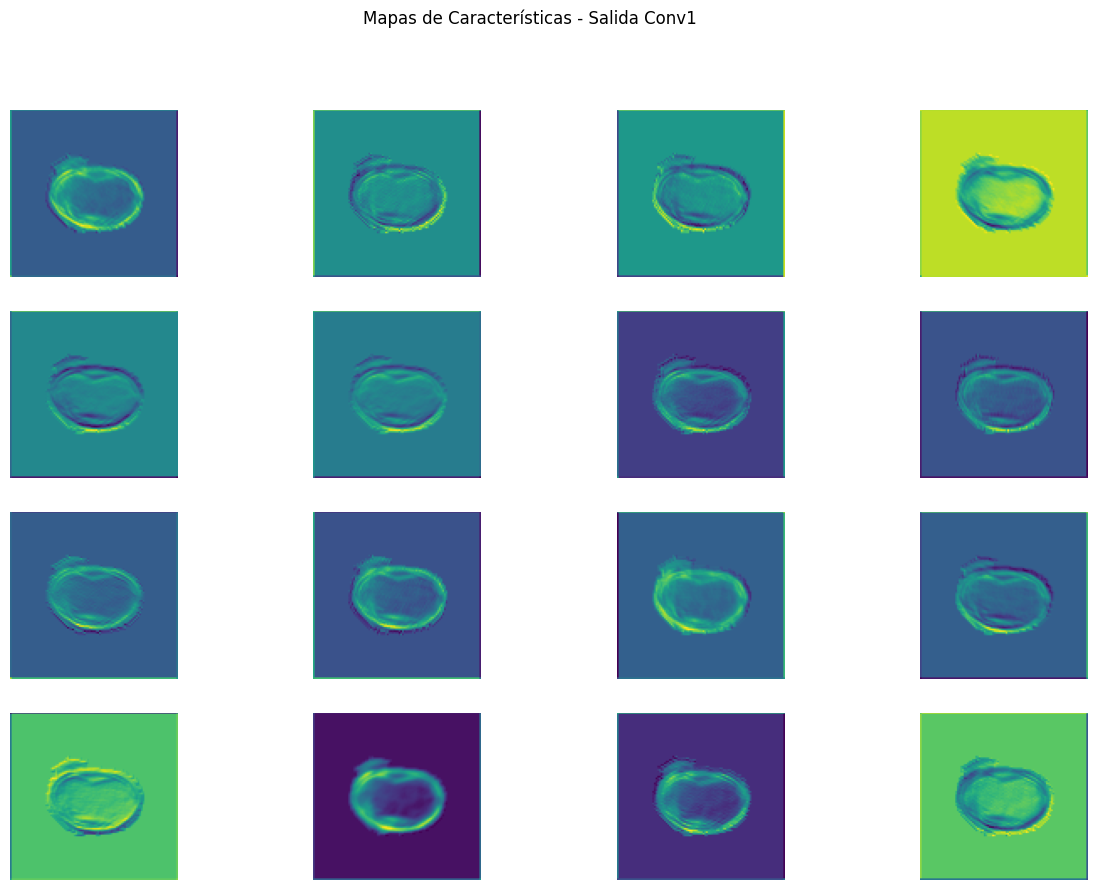

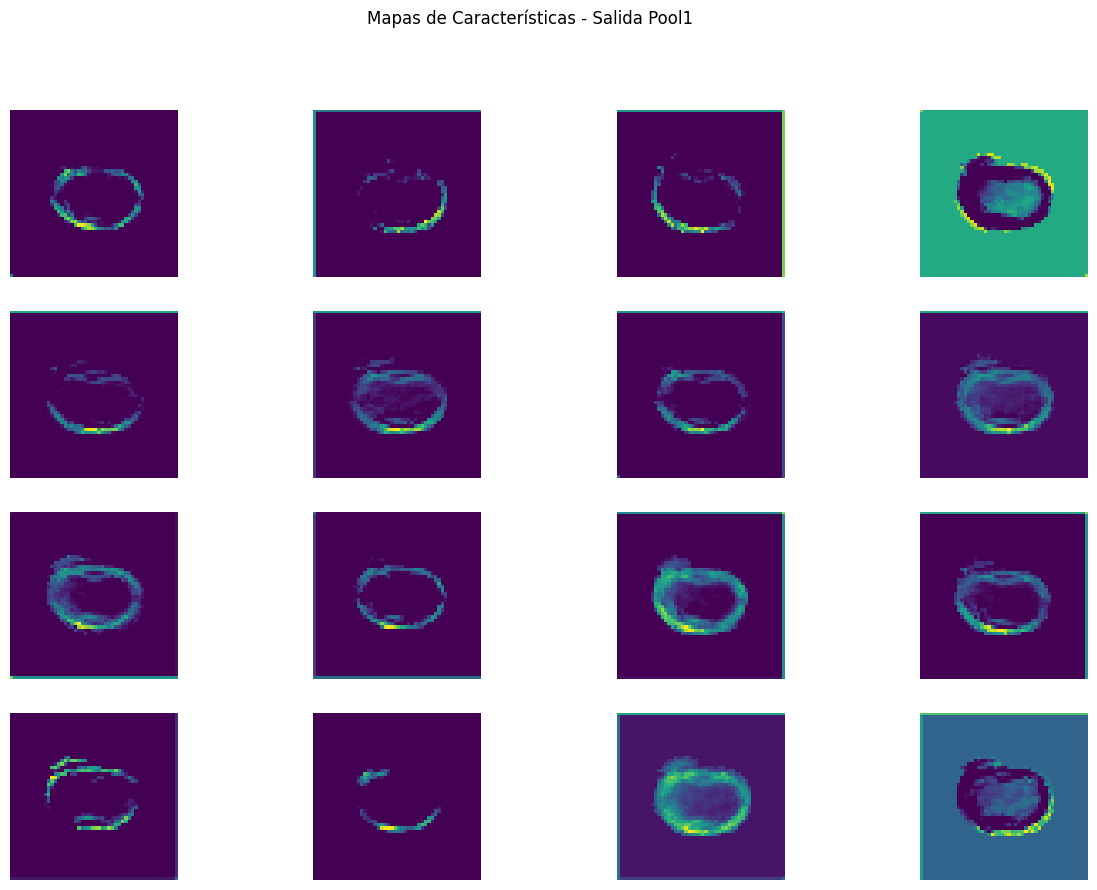

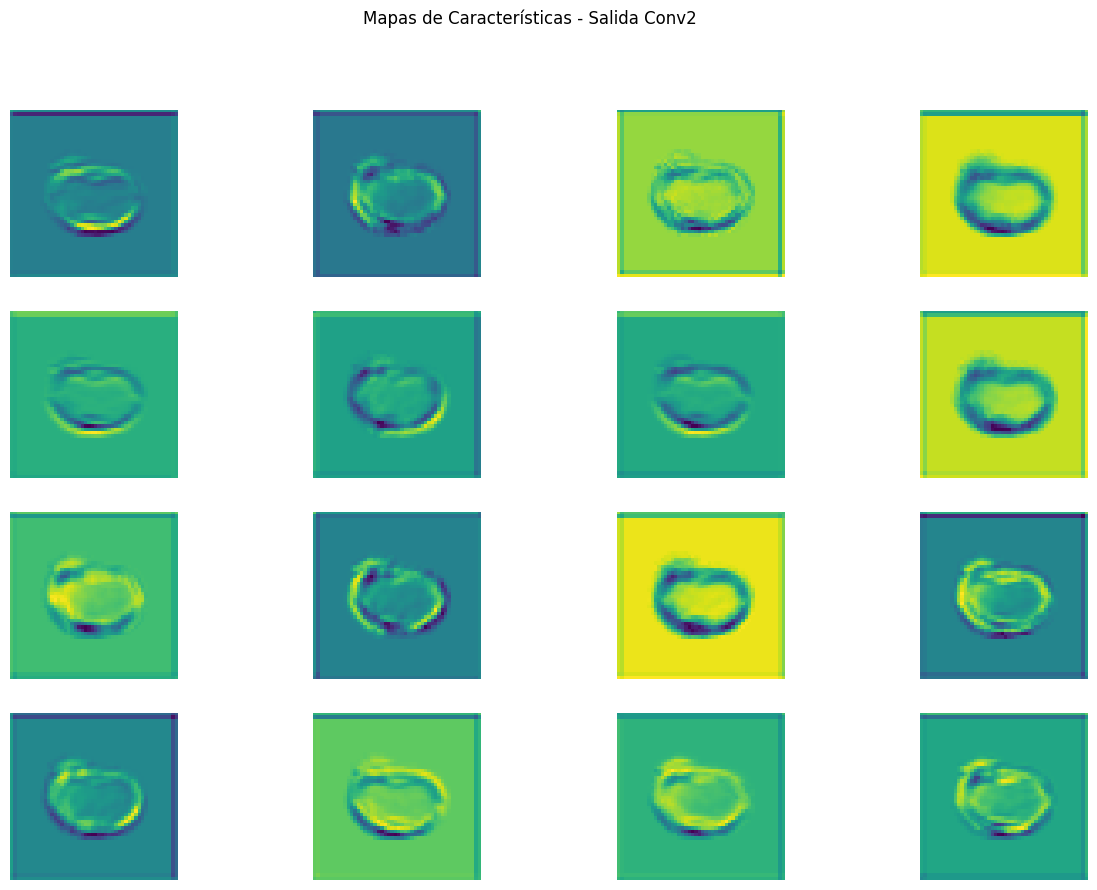

In [17]:

def plot_feature_maps(feature_maps, title, filename=None):
    n_maps = feature_maps.shape[1]
    plt.figure(figsize=(15, 10))
    # Mostramos hasta 16 mapas
    for i in range(min(n_maps, 16)):
        plt.subplot(4, 4, i + 1)
        plt.imshow(feature_maps[0, i].detach().cpu().numpy(), cmap='viridis')
        plt.axis('off')
    plt.suptitle(title)
    if filename: plt.savefig(filename, bbox_inches='tight')
    plt.show()

# 1. Obtener una imagen de test
it = iter(dm.test_dataloader())
images, labels = next(it)
img = images[0:1].to(modelo_visual.device)
label = labels[0]

# Aplicamos normalización manual ya que dm.test_dataloader devuelve imagenes base
img = gpu_val_test_transforms(img)

plt.imshow(img.cpu().squeeze(), cmap='gray')
plt.title(f"Imagen Original (Clase: {dm.classes[label]})")
plt.axis('off')
plt.show()

# 2. Pasar por la primera capa
with torch.no_grad():
    x1 = modelo_visual.model[0](img) # Conv1
    plot_feature_maps(x1, "Mapas de Características - Salida Conv1")
    
    x1_pool = modelo_visual.model[2](modelo_visual.model[1](x1)) # ReLU + Pool1
    plot_feature_maps(x1_pool, "Mapas de Características - Salida Pool1")

    # 3. Pasar por la segunda capa
    x2 = modelo_visual.model[3](x1_pool) # Conv2
    plot_feature_maps(x2, "Mapas de Características - Salida Conv2")


# Fase 3: Análisis de Pesos y Mapas de Características

## 1. Carga del Modelo Base (CNN)
Cargamos los pesos del entrenamiento previo (Fase 2) para el Modelo 3.

In [5]:

#cleanup()
# Re-definimos la arquitectura del Modelo 3 (Base)
cnn_base_arch = nn.Sequential(
    nn.Conv2d(1, 16, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
    nn.Conv2d(16, 32, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
    nn.Flatten(), nn.Linear(32 * 25 * 25, 16), nn.ReLU(), nn.Linear(16, 1)
)

# Cargamos el checkpoint (Version 2 fue la más completa)
checkpoint_path = 'logs/cnn_base/version_7/checkpoints/epoch=26-step=810.ckpt'
modelo_visual = RedNeuronal.load_from_checkpoint(
    checkpoint_path, 
    model=cnn_base_arch,
    is_cnn=True
)
modelo_visual.eval() # Modo evaluación
print("Modelo cargado correctamente para análisis.")


NameError: name 'RedNeuronal' is not defined

## 2. Visualización de Filtros (Pesos)
Visualizamos los filtros de la primera capa convolucional para identificar patrones de bajo nivel.

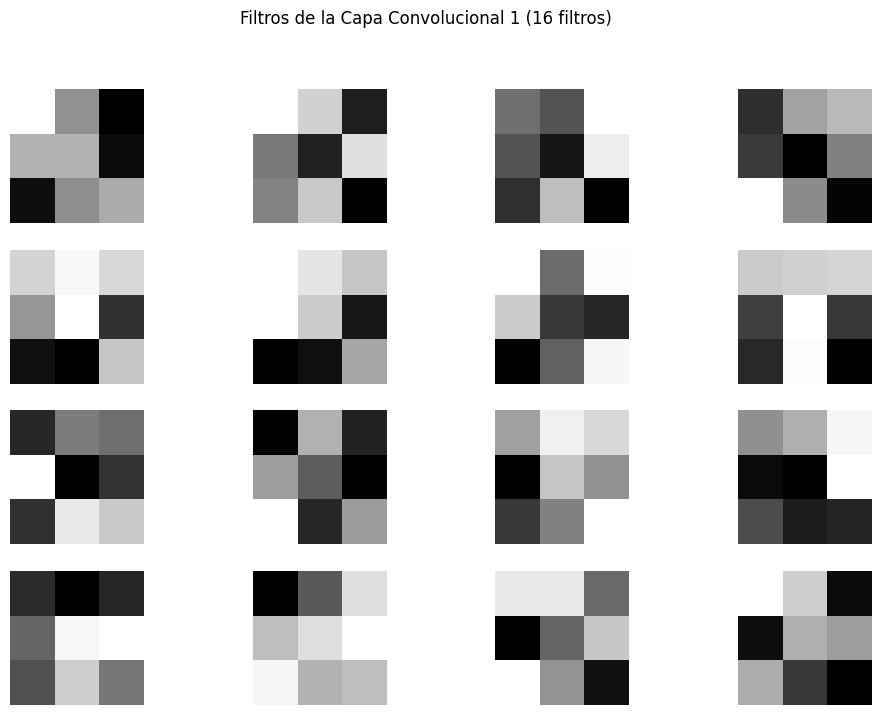

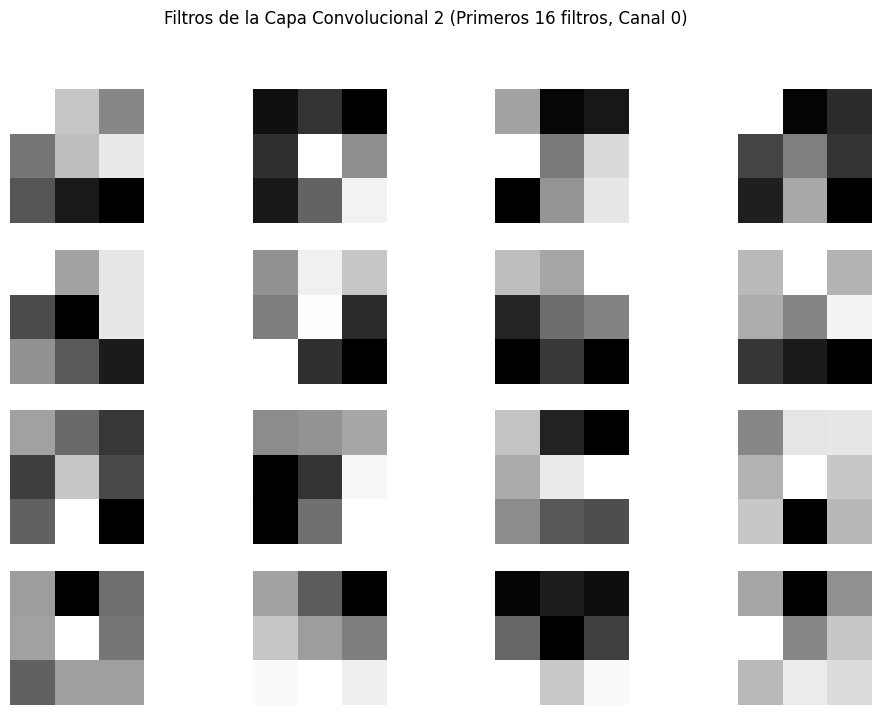

In [ ]:

def plot_filters(layer_weights, title, filename=None):
    filters = layer_weights.detach().cpu()
    n_filters = filters.shape[0]
    plt.figure(figsize=(12, 8))
    for i in range(n_filters):
        plt.subplot(4, 4, i + 1)
        # Normalizamos para mejor visualización
        f_min, f_max = filters[i].min(), filters[i].max()
        filter_img = (filters[i] - f_min) / (f_max - f_min)
        plt.imshow(filter_img.squeeze(), cmap='gray')
        plt.axis('off')
    plt.suptitle(title)
    if filename: plt.savefig(filename, bbox_inches='tight')
    plt.show()

# Capa 1: Conv2d(1, 16, ...)
plot_filters(modelo_visual.model[0].weight, "Filtros de la Capa Convolucional 1 (16 filtros)", "filtros_conv1.png")

# Capa 2: Conv2d(16, 32, ...) - Visualizamos solo los primeros 16 del primer canal de entrada
plot_filters(modelo_visual.model[3].weight[:, 0, :, :][:16], "Filtros de la Capa Convolucional 2 (Primeros 16 filtros, Canal 0)", "filtros_conv2.png")


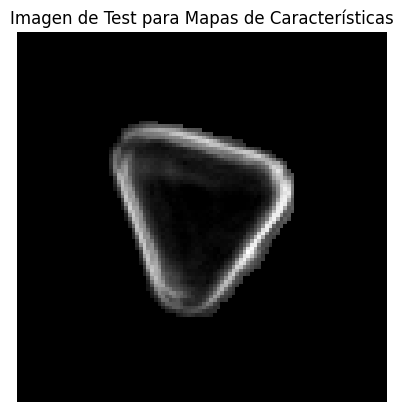

In [ ]:
kunzea_img = ImageFolder(root='dataset/anuka1200', transform=base_transforms)[0][0].unsqueeze(0).to(modelo_visual.device)
kunzea_img = gpu_val_test_transforms(kunzea_img)
plt.imshow(kunzea_img.cpu().squeeze(), cmap='gray')
plt.title("Imagen de Test para Mapas de Características")
plt.axis('off')
plt.show()

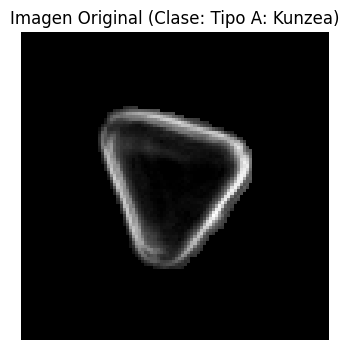

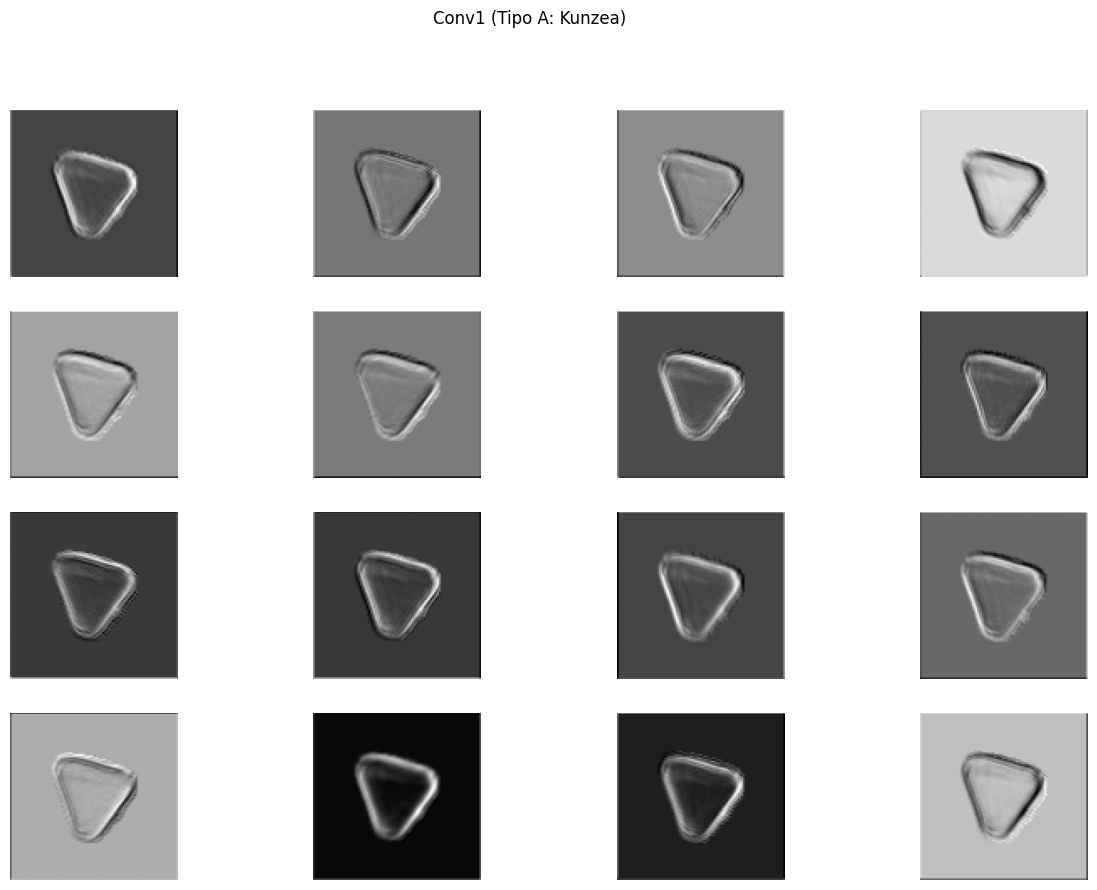

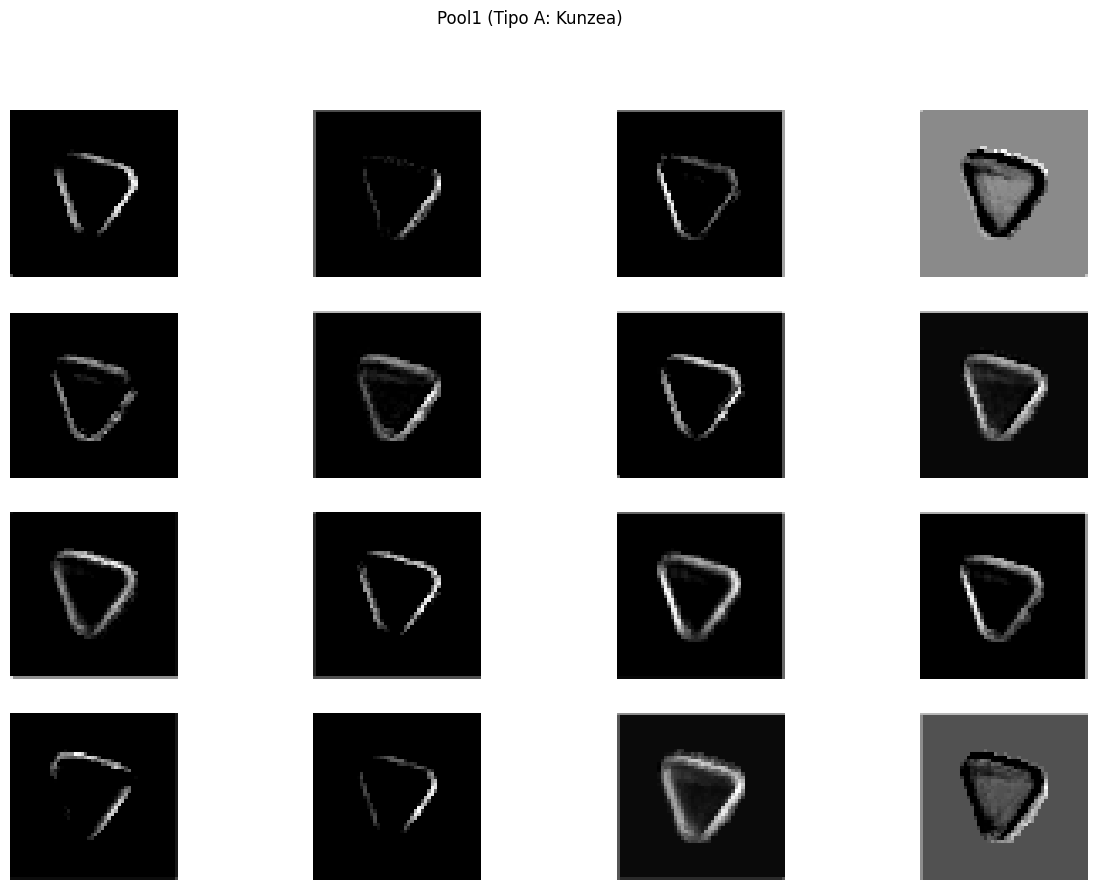

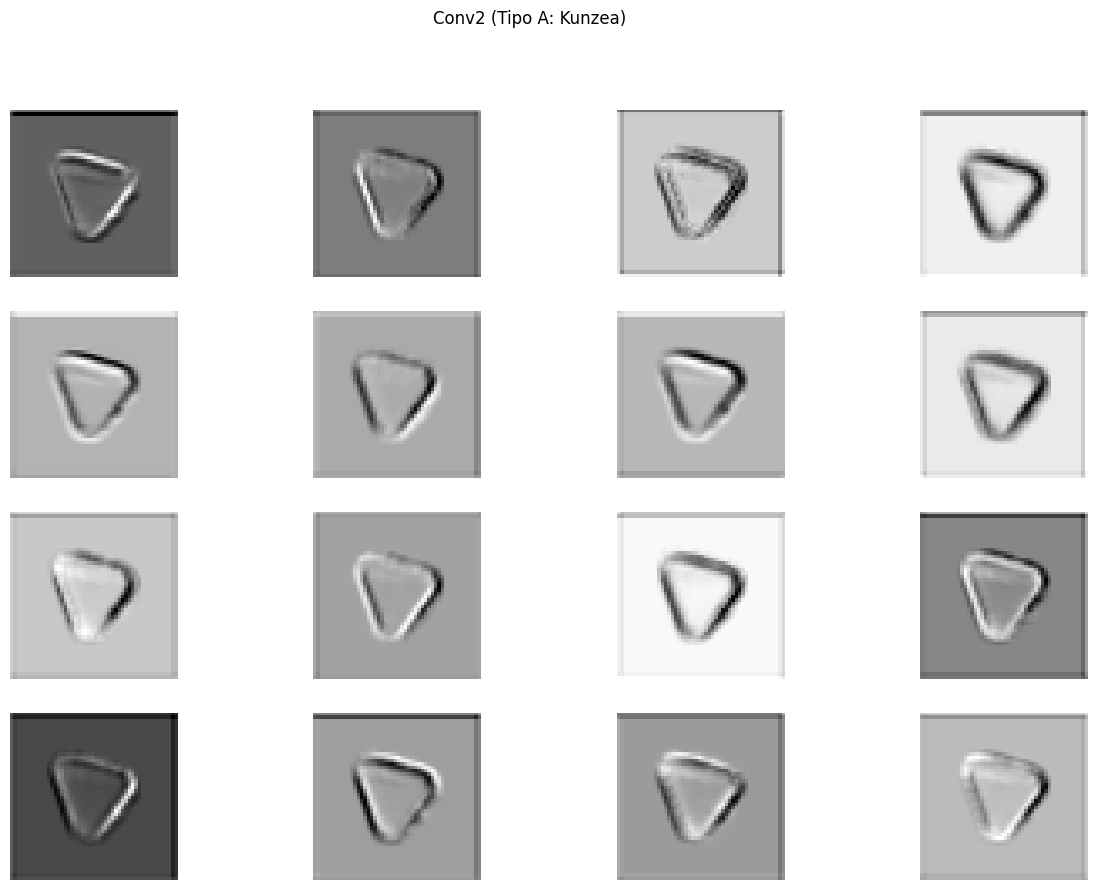

In [ ]:
%matplotlib inline

import numpy as np

def _tensor_to_image(t):
    a = t.detach().cpu().numpy()
    # a puede ser (1,C,H,W) o (B,C,H,W) o (C,H,W)
    if a.ndim == 4:
        a = a[0]
    if a.shape[0] == 1:
        return a.squeeze(0)        # HxW grayscale
    elif a.shape[0] == 3:
        return np.transpose(a, (1,2,0))  # HxWx3
    else:
        return a.squeeze()

def plot_feature_maps(feature_maps, title, filename=None):
    maps = feature_maps.detach().cpu().numpy()
    if maps.ndim == 4:
        maps = maps[0]  # C,H,W
    n_maps = maps.shape[0]
    plt.figure(figsize=(15,10))
    for i in range(min(n_maps,16)):
        plt.subplot(4,4,i+1)
        plt.imshow(maps[i], cmap='gray')
        plt.axis('off')
    plt.suptitle(title)
    if filename: plt.savefig(filename, bbox_inches='tight')
    plt.show()

def procesar_y_visualizar(img, clase_nombre):
    img_np = _tensor_to_image(img)
    plt.figure(figsize=(4,4))
    cmap = 'gray' if img_np.ndim == 2 else None
    plt.imshow(img_np, cmap=cmap)
    plt.title(f"Imagen Original (Clase: {clase_nombre})")
    plt.axis('off')
    plt.show()

    with torch.no_grad():
        x1 = modelo_visual.model[0](img)
        plot_feature_maps(x1, f"Conv1 ({clase_nombre})")
        x1_pool = modelo_visual.model[2](modelo_visual.model[1](x1))
        plot_feature_maps(x1_pool, f"Pool1 ({clase_nombre})")
        x2 = modelo_visual.model[3](x1_pool)
        plot_feature_maps(x2, f"Conv2 ({clase_nombre})")

procesar_y_visualizar(kunzea_img, "Tipo A: Kunzea")


## 3. Visualización de Mapas de Características
Pasamos una imagen por la red y capturamos las activaciones de las capas convolucionales.

--- Procesando imagen Kunzea ---


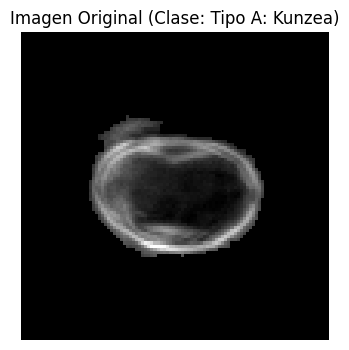

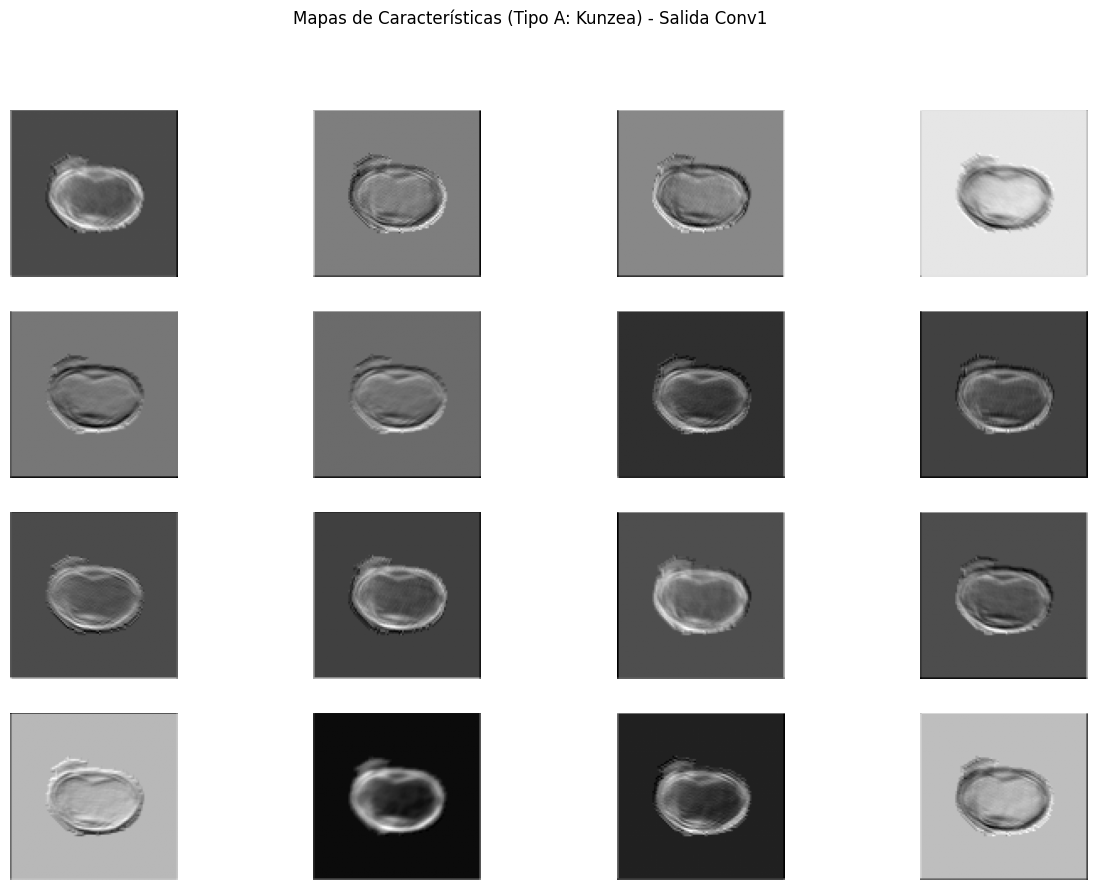

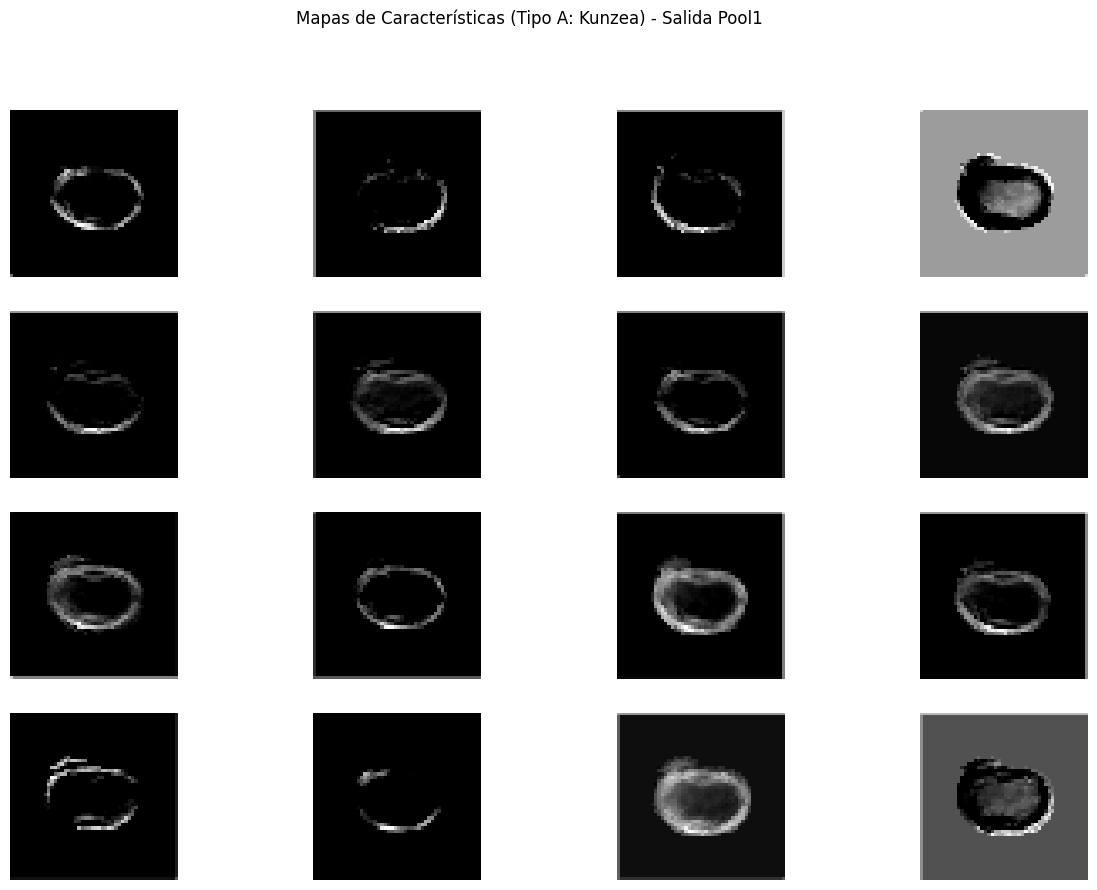

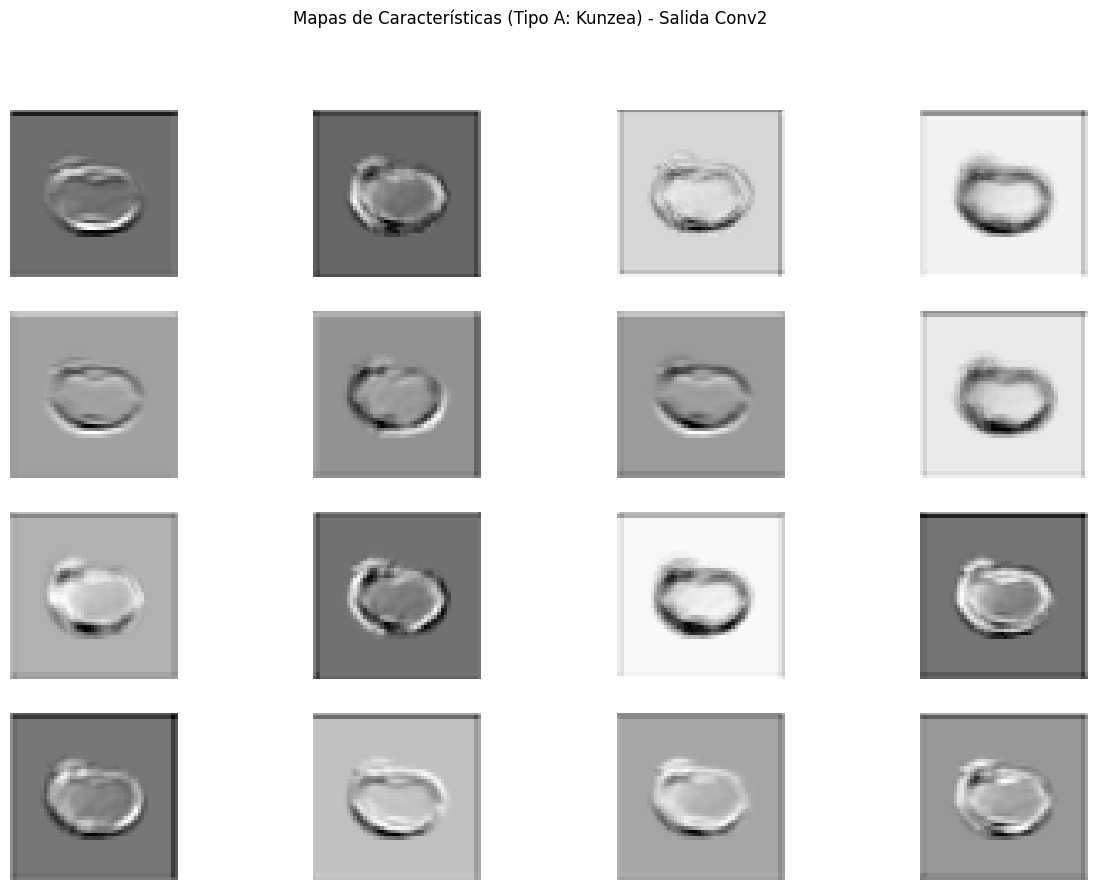


--- Procesando imagen Lepto ---


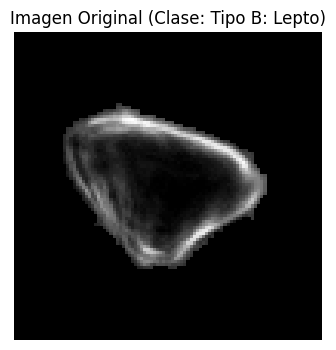

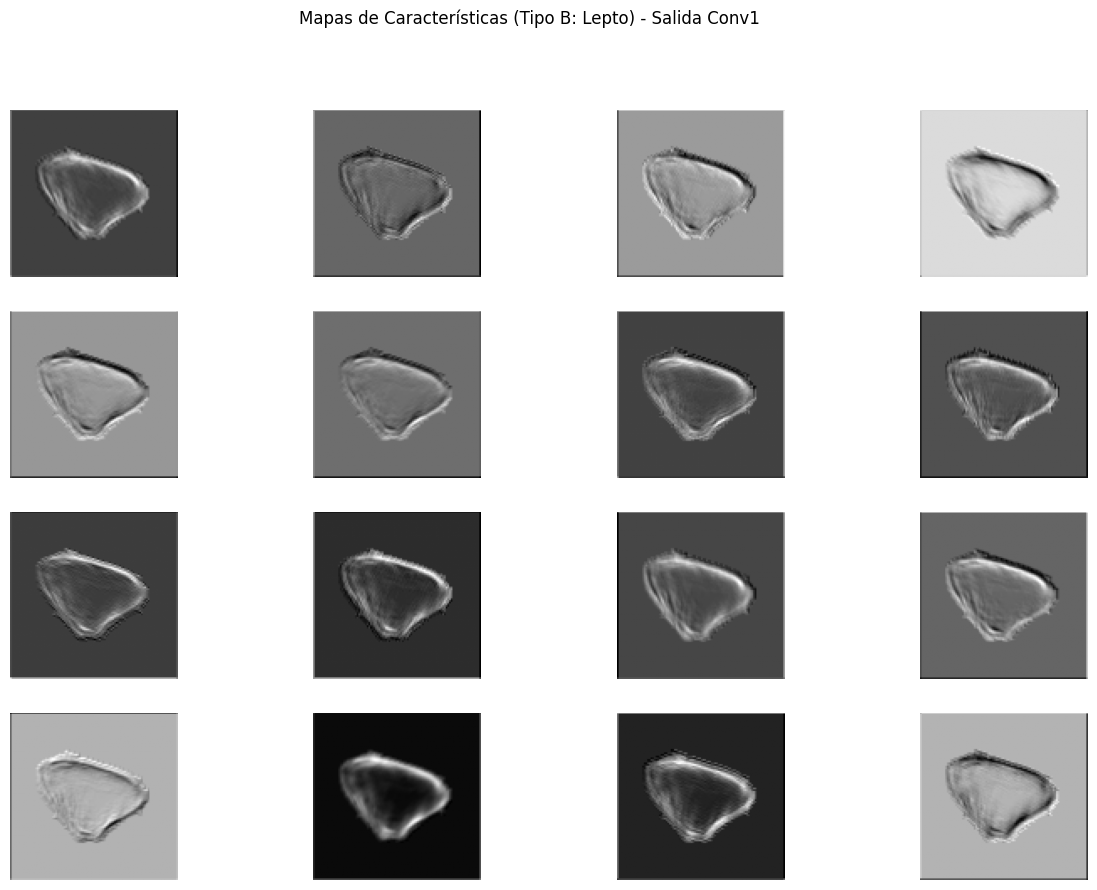

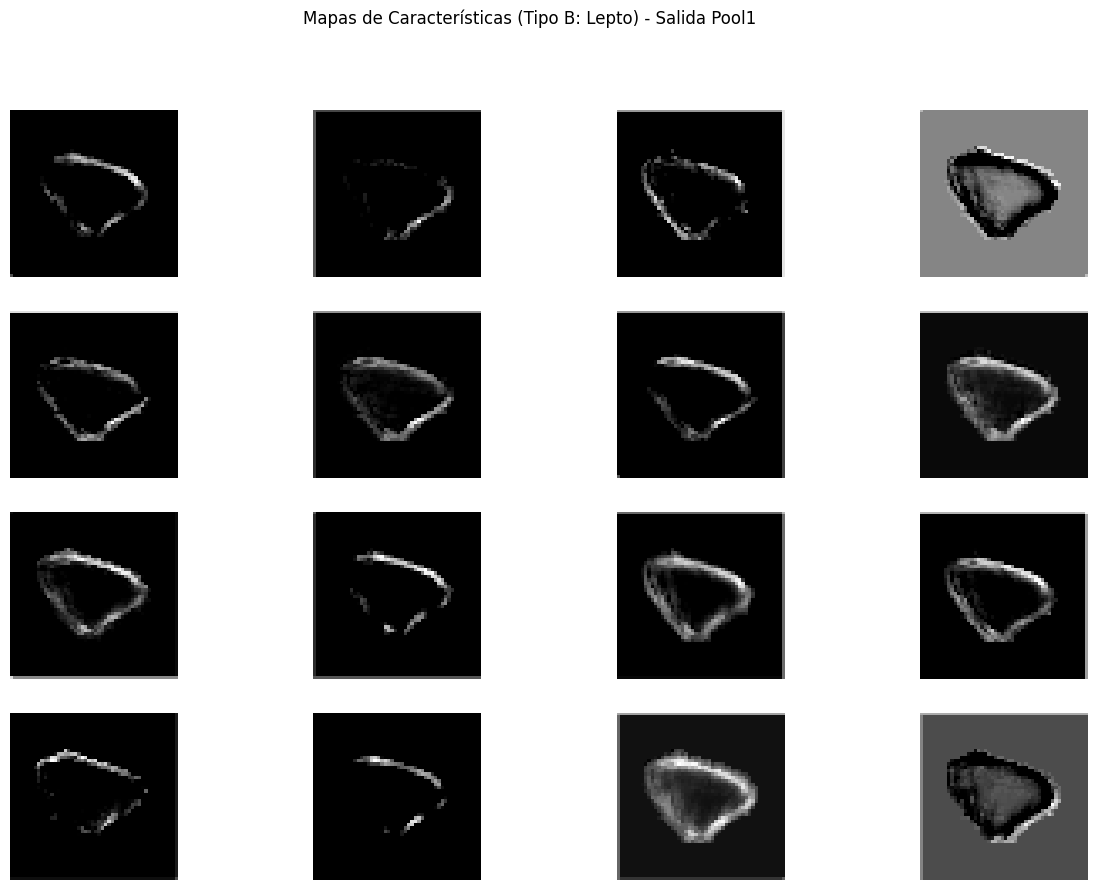

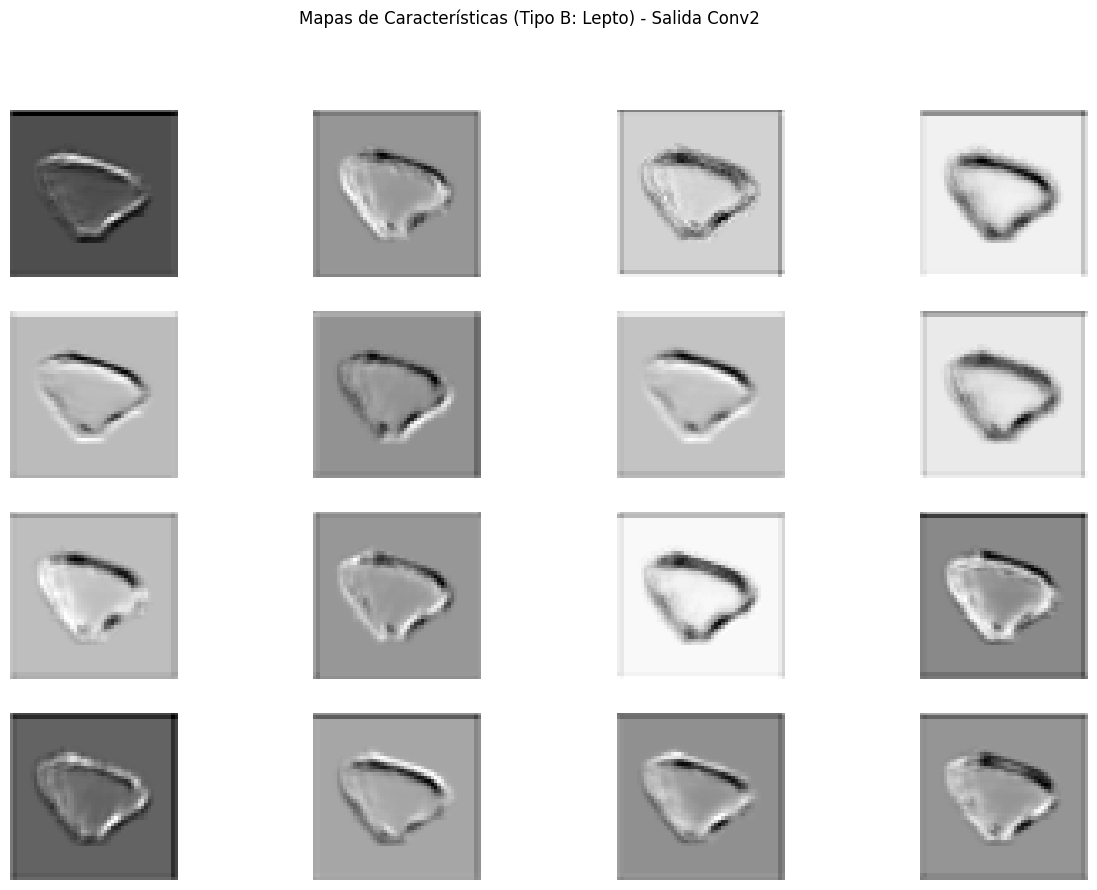

In [ ]:

def plot_feature_maps(feature_maps, title, filename=None):
    n_maps = feature_maps.shape[1]
    plt.figure(figsize=(15, 10))
    # Mostramos hasta 16 mapas
    for i in range(min(n_maps, 16)):
        plt.subplot(4, 4, i + 1)
        plt.imshow(feature_maps[0, i].detach().cpu().numpy(), cmap='gray')
        plt.axis('off')
    plt.suptitle(title)
    if filename: plt.savefig(filename, bbox_inches='tight')
    plt.show()

# 1. Obtener imágenes de test (una Kunzea y una Lepto)
it = iter(dm.test_dataloader())
kunzea_img = None
lepto_img = None

while kunzea_img is None or lepto_img is None:
    try:
        images, labels = next(it)
    except StopIteration:
        break
    for i in range(len(labels)):
        # Asumiendo dm.classes = ['Tipo A: Kunzea', 'Tipo B: Lepto']
        if labels[i] == 0 and kunzea_img is None: 
            kunzea_img = images[i:i+1]
        elif labels[i] == 1 and lepto_img is None: 
            lepto_img = images[i:i+1]

# Aplicamos normalización manual ya que dm.test_dataloader devuelve imagenes base
kunzea_img = gpu_val_test_transforms(kunzea_img).to(modelo_visual.device)
lepto_img = gpu_val_test_transforms(lepto_img).to(modelo_visual.device)

# Función para visualizar y procesar una imagen
def procesar_y_visualizar(img, clase_nombre):
    safe_name = clase_nombre.replace(':', '').replace(' ', '_')
    plt.figure(figsize=(4, 4))
    plt.imshow(img.cpu().squeeze(), cmap='gray')
    plt.title(f"Imagen Original (Clase: {clase_nombre})")
    plt.axis('off')
    plt.savefig(f'original_{safe_name}.png', bbox_inches='tight')
    plt.show()

    # Pasar por la primera capa
    with torch.no_grad():
        x1 = modelo_visual.model[0](img) # Conv1
        plot_feature_maps(x1, f"Mapas de Características ({clase_nombre}) - Salida Conv1", f"mapas_conv1_{safe_name}.png")
        
        x1_pool = modelo_visual.model[2](modelo_visual.model[1](x1)) # ReLU + Pool1
        plot_feature_maps(x1_pool, f"Mapas de Características ({clase_nombre}) - Salida Pool1", f"mapas_pool1_{safe_name}.png")

        # Pasar por la segunda capa
        x2 = modelo_visual.model[3](x1_pool) # Conv2
        plot_feature_maps(x2, f"Mapas de Características ({clase_nombre}) - Salida Conv2", f"mapas_conv2_{safe_name}.png")

print("--- Procesando imagen Kunzea ---")
procesar_y_visualizar(kunzea_img, "Tipo A: Kunzea")

print("\n--- Procesando imagen Lepto ---")
procesar_y_visualizar(lepto_img, "Tipo B: Lepto")


Historia CNN Base:


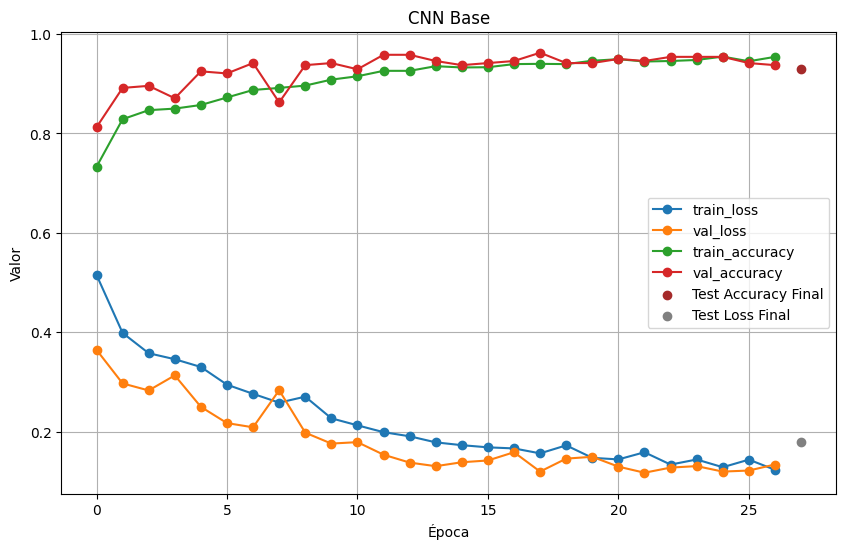

Historia CNN Variante A:


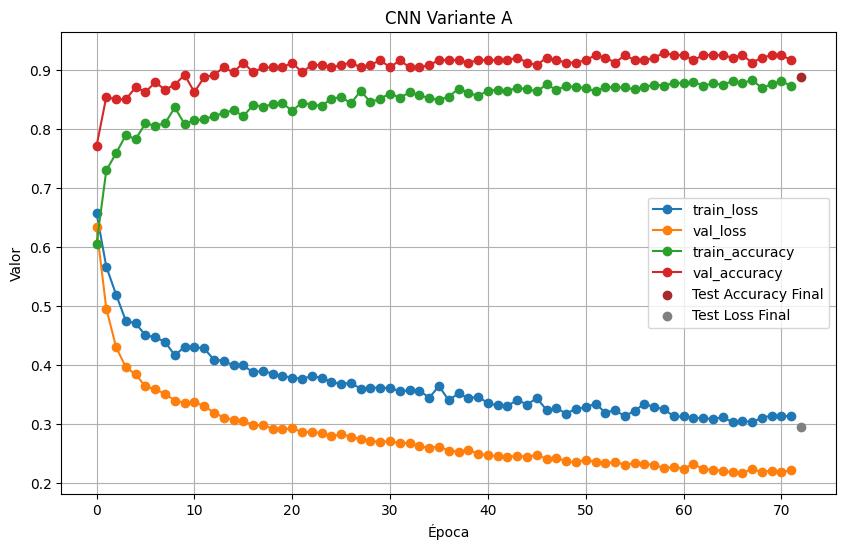

Historia CNN Variante B:


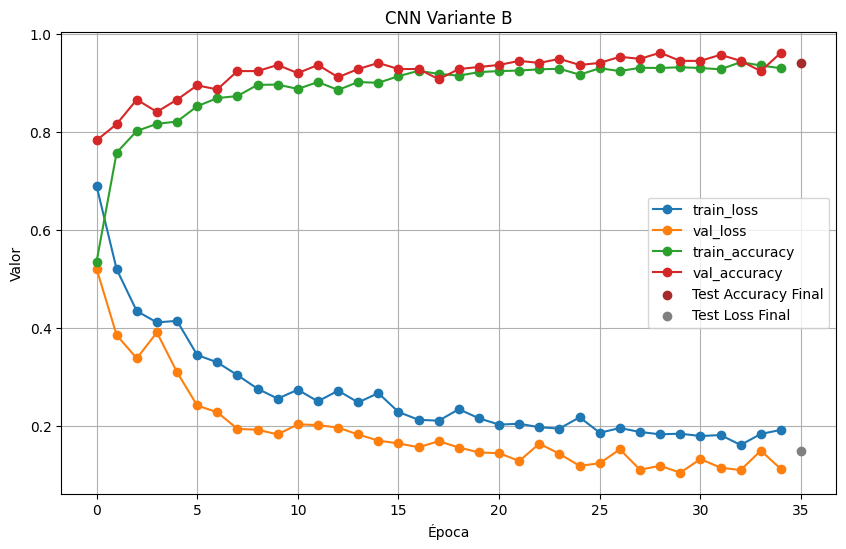

Historia Red Neuronal 1:


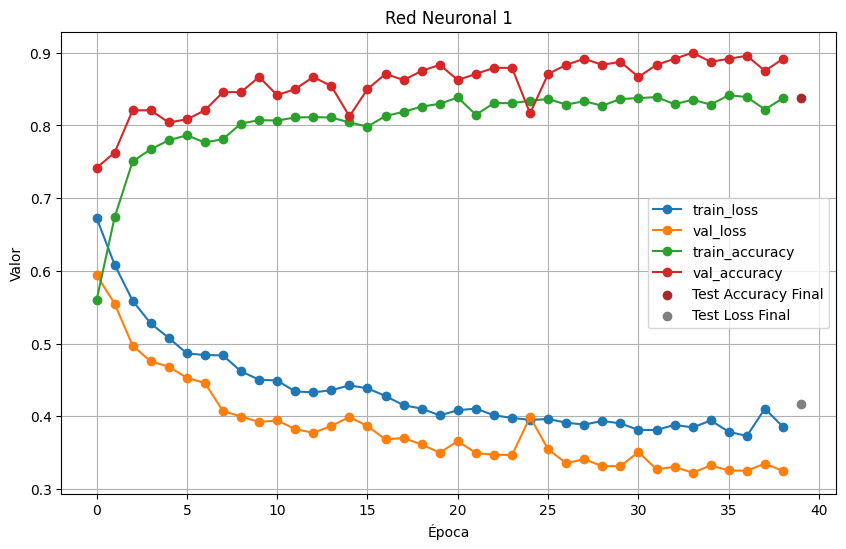

Historia Red Neuronal 2:


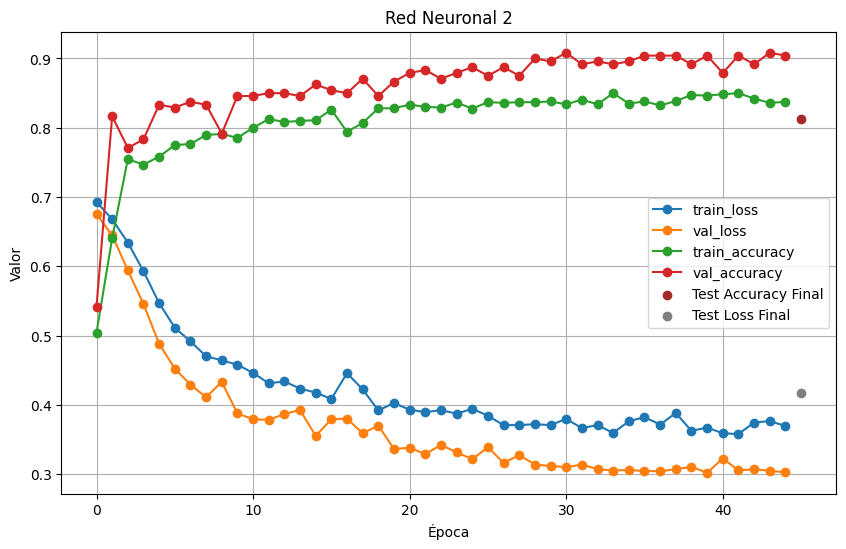

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
cnn_base_history = pd.read_csv('logs/cnn_base/version_7/metrics.csv')
cnn_var_a_history = pd.read_csv('logs/cnn_var_a/version_6/metrics.csv')
cnn_var_b_history = pd.read_csv('logs/cnn_var_b/version_5/metrics.csv')
net_1_history = pd.read_csv('logs/net1/version_9/metrics.csv')
net_2_history = pd.read_csv('logs/net2/version_6/metrics.csv')


def plot_history(df, model_name, filename=None):
    df.groupby("epoch").mean().reset_index().plot(x='epoch', y=['train_loss', 'val_loss', 'train_accuracy', 'val_accuracy'], figsize=(10,6), marker='o')
    
    last_epoch = df.epoch.iloc[-1]
    final_acc = df.test_accuracy.iloc[-1]
    final_loss = df.test_loss.iloc[-1]

    plt.scatter(x=last_epoch, y= final_acc, color='brown', label='Test Accuracy Final', zorder=5)
    plt.annotate(f'{final_acc:.2f}', 
                 (last_epoch, final_acc),
                 textcoords="offset points", # Desplazamiento en puntos
                 xytext=(0,10),              # 10 puntos hacia arriba
                 ha='center',                # Alineación horizontal
                 color='brown',
                 weight='bold')
    plt.scatter(x=last_epoch, y=final_loss, color='gray', label='Test Loss Final', zorder=5)
    plt.annotate(f'{final_loss:.2f}', 
                 (last_epoch, final_loss),
                 textcoords="offset points", 
                 xytext=(0,10), 
                 ha='center', 
                 color='gray',
                 weight='bold')
    
    plt.title(model_name)
    plt.xlabel('Época')
    plt.ylabel('Valor')
    plt.grid()
    plt.legend()
    if filename:
        plt.savefig("training/" +filename)
    plt.show()

print("Historia CNN Base:")
plot_history(cnn_base_history, "CNN Base", filename="base_cnn.png")
print("Historia CNN Variante A:")
plot_history(cnn_var_a_history, "CNN Variante A", filename="cnn_var_a.png")
print("Historia CNN Variante B:")
plot_history(cnn_var_b_history, "CNN Variante B", filename="cnn_var_b.png")
print("Historia Red Neuronal 1:")
plot_history(net_1_history, "Red Neuronal 1", filename="mlp_1.png")
print("Historia Red Neuronal 2:")
plot_history(net_2_history, "Red Neuronal 2", filename="mlp_2.png")



In [ ]:
cnn_base_history.columns
cnn_var_b_history.groupby("epoch").agg({"train_loss": "mean", "val_loss": "mean", "train_accuracy": "mean", "val_accuracy": "mean"})
last_epoch = cnn_base_history.epoch.iloc[-1]
test_acc = cnn_base_history.test_accuracy.iloc[-1]
test_loss = cnn_base_history.test_loss.iloc[-1]
print(f"Último epoch registrado: {last_epoch}, Test Accuracy: {test_acc:.4f}")

Último epoch registrado: 72, Test Accuracy: 0.8667


## 4. Análisis Crítico (Entregable)

A partir de las visualizaciones anteriores, podemos extraer las siguientes conclusiones sobre cómo la red neuronal convolucional aprende a clasificar los granos de polen:

**Patrones observados (Filtros de las capas 1 y 2):**
- En la **Capa Convolucional 1**, los filtros actúan como detectores de características de bajo nivel. Se observan filtros especializados en la detección de bordes (verticales, horizontales, diagonales), gradientes de intensidad luminosa y texturas elementales. Por su naturaleza visual, estos primeros filtros extraen los contornos básicos que delinean los granos de polen.
- En la **Capa Convolucional 2**, los filtros aprenden representaciones de nivel intermedio combinando las salidas de la capa anterior. Aquí se pueden observar patrones más difusos, los cuales capturan texturas y curvaturas de la pared (exina) y características de las aperturas de la pared.

**Evolución de características (Mapas de Características):**
- A la salida de la **Conv1**, las activaciones conservan casi totalmente la resolución espacial (la imagen sólo sufre una leve reducción debido a la ausencia de un padding excesivo o por el pool). Las imágenes resaltan claramente los bordes estructurales del objeto de interés en contraste con el fondo.
- Tras la capa de agregación **(Pool1)**, la dimensionalidad se reduce, destacando sólo los rasgos más persistentes y prominentes y eliminando redundancias, haciendo al modelo más robusto (invariante espacialmente a pequeñas traslaciones).
- A la salida de la **Conv2**, la representación se aleja cada vez más del aspecto original de la imagen. La información visual evoluciona hacia una abstracción puramente semántica en forma de mapas de calor, donde los píxeles más brillantes indican regiones altamente activadas por un rasgo morfológico específico aprendido.

**Aprendizaje de información relevante:**
- Al comparar las respuestas frente a una imagen *Kunzea* y otra *Lepto*, se evidencia que, aunque las primeras capas reaccionan a ambos de forma similar (enfocadas en sus bordes circulares/elípticos genéricos), los mapas de características de la capa final se diferencian en intensidad y ubicación. Esto señala que la red localiza regiones focales discriminativas para el clasificador lineal final: por ejemplo, diferencias de textura en el interior, la presencia de engrosamientos de pared, o la relación de forma (aspect ratio), prestando menos atención a partes no informativas como el fondo liso.
